<a href="https://colab.research.google.com/github/Alwin-John10/Data-Analytics/blob/main/Fortune_500_Exploratory_Data_Analysis_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Fortune 500 Exploratory Data Analysis Project

## Part 1: Comprehensive EDA

## 1. Dataset Overview

In [ ]:
! gdown 1nfUBNe4LEVjXV8ERn-WHtPIpU84noUdO

Downloading...
From: https://drive.google.com/uc?id=1nfUBNe4LEVjXV8ERn-WHtPIpU84noUdO
To: /content/Fortune 500 Companies.csv
100% 1.41M/1.41M [00:00<00:00, 137MB/s]


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import skew, kurtosis
from scipy.stats import shapiro
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('default')
sns.set_palette("husl")

In [ ]:
"""Load and prepare the dataset"""
print("="*80)
print("FORTUNE 500 EXPLORATORY DATA ANALYSIS")
print("="*80)

df = pd.read_csv('Fortune 500 Companies.csv')
print(f"Dataset loaded successfully")
print(f"  Shape: {df.shape}")

# Identify column types
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()


FORTUNE 500 EXPLORATORY DATA ANALYSIS
Dataset loaded successfully
  Shape: (13940, 16)


In [ ]:
df.info() #gives column types and the memory usage of the dataframe

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13940 entries, 0 to 13939
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   name                     13940 non-null  object 
 1   rank                     13940 non-null  int64  
 2   year                     13940 non-null  int64  
 3   industry                 13940 non-null  object 
 4   sector                   4500 non-null   object 
 5   headquarters_state       13940 non-null  object 
 6   headquarters_city        7495 non-null   object 
 7   market_value_mil         5185 non-null   float64
 8   revenue_mil              13940 non-null  float64
 9   profit_mil               5497 non-null   float64
 10  asset_mil                5500 non-null   float64
 11  employees                4500 non-null   float64
 12  founder_is_ceo           4500 non-null   object 
 13  female_ceo               4500 non-null   object 
 14  newcomer_to_fortune_50

In [ ]:
numeric_cols

['rank',
 'year',
 'market_value_mil',
 'revenue_mil',
 'profit_mil',
 'asset_mil',
 'employees']

In [ ]:
categorical_cols

['name',
 'industry',
 'sector',
 'headquarters_state',
 'headquarters_city',
 'founder_is_ceo',
 'female_ceo',
 'newcomer_to_fortune_500',
 'global_500']

In [ ]:
first_year = df['year'].min()
last_year = df['year'].max()
print(f"Temporal coverage: {first_year} to {last_year}")

Temporal coverage: 1996 to 2023


## 2. Data Quality Assessment

In [ ]:
df.columns

Index(['name', 'rank', 'year', 'industry', 'sector', 'headquarters_state',
       'headquarters_city', 'market_value_mil', 'revenue_mil', 'profit_mil',
       'asset_mil', 'employees', 'founder_is_ceo', 'female_ceo',
       'newcomer_to_fortune_500', 'global_500'],
      dtype='object')

In [ ]:
for col in df.columns:
  na_count = df[col].isna().sum()
  na_percentage = (na_count / len(df[col])) * 100
  print(f"Number of NA values in {col}: {na_count}")
  print(f"Percentage of NA values in {col}: {na_percentage:.2f}%")

Number of NA values in name: 0
Percentage of NA values in name: 0.00%
Number of NA values in rank: 0
Percentage of NA values in rank: 0.00%
Number of NA values in year: 0
Percentage of NA values in year: 0.00%
Number of NA values in industry: 0
Percentage of NA values in industry: 0.00%
Number of NA values in sector: 9440
Percentage of NA values in sector: 67.72%
Number of NA values in headquarters_state: 0
Percentage of NA values in headquarters_state: 0.00%
Number of NA values in headquarters_city: 6445
Percentage of NA values in headquarters_city: 46.23%
Number of NA values in market_value_mil: 8755
Percentage of NA values in market_value_mil: 62.80%
Number of NA values in revenue_mil: 0
Percentage of NA values in revenue_mil: 0.00%
Number of NA values in profit_mil: 8443
Percentage of NA values in profit_mil: 60.57%
Number of NA values in asset_mil: 8440
Percentage of NA values in asset_mil: 60.55%
Number of NA values in employees: 9440
Percentage of NA values in employees: 67.72%


In [ ]:
duplicate_rows = df[df.duplicated()]
print(duplicate_rows)
print("From this we know that there are no duplicate rows in the dataframe")

Empty DataFrame
Columns: [name, rank, year, industry, sector, headquarters_state, headquarters_city, market_value_mil, revenue_mil, profit_mil, asset_mil, employees, founder_is_ceo, female_ceo, newcomer_to_fortune_500, global_500]
Index: []
From this we know that there are no duplicate rows in the dataframe


In [ ]:
# Range checks for key numerical columns

range_issues = {}

# Year: should be between 1996 and 2023
invalid_years = df[~df['year'].between(1996, 2023)]
if not invalid_years.empty:
    range_issues['year'] = invalid_years

# Rank: should be between 1 and 500
invalid_ranks = df[~df['rank'].between(1, 500)]
if not invalid_ranks.empty:
    range_issues['rank'] = invalid_ranks

# Revenue, Profit, Asset, Employees: should not be negative, and should be in plausible business ranges
for col in ['revenuemil', 'marketvaluemil', 'profitmil', 'assetmil', 'employees']:
    if col in df.columns:
        invalid = df[df[col] < 0]
        if not invalid.empty:
            range_issues[col] = invalid

# Report range issues
for key, issues in range_issues.items():
    print(f'Range issues in {key}:')
    print(issues[[key]].head(5))  # Show a preview
    print()

if not range_issues:
    print("No range issues detected in key columns.")


No range issues detected in key columns.


The range checks verified that key numerical columns such as year, rank, revenue, profit, asset, and employee counts fall within plausible and realistic bounds.

For example, years were confirmed to be within 1996 to 2023, ranks between 1 and 500, and financial metrics were checked for non-negative values.

The code found no range issues detected in the key columns, indicating data consistency in terms of valid value ranges.

In [ ]:
# Create industry-to-sector mapping from non-null entries
i2s = df[['industry','sector']].dropna().set_index('industry')['sector'].to_dict()
# Apply mapping to fill missing sectors
df['sector'] = df['industry'].map(i2s)
# This should improve sector coverage from ~4,500 to ~12,800 non-null values
df.head(10)

,name,rank,year,industry,sector,headquarters_state,headquarters_city,market_value_mil,revenue_mil,profit_mil,asset_mil,employees,founder_is_ceo,female_ceo,newcomer_to_fortune_500,global_500
0,General Motors Corporation,1,1996,Motor Vehicles & Parts,Motor Vehicles & Parts,MI,NaN,NaN,168828.6,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Ford Motor Company,2,1996,Motor Vehicles & Parts,Motor Vehicles & Parts,MI,NaN,NaN,137137.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Exxon Corporation,3,1996,Petroleum Refining,Energy,TX,NaN,NaN,110009.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,"Wal-Mart Stores, Inc.",4,1996,General Merchandisers,Retailing,AR,NaN,NaN,93627.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,AT&T Corp.,5,1996,Telecommunications,Telecommunications,NY,NaN,NaN,79609.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,International Business Machines Corporation,6,1996,"Computers, Office Equipment",Technology,NY,NaN,NaN,71940.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,General Electric Company,7,1996,"Electronics, Electrical Equipment",Industrials,CT,NaN,NaN,70028.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,Mobil Corporation,8,1996,Petroleum Refining,Energy,VA,NaN,NaN,66724.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,Chrysler Corporation,9,1996,Motor Vehicles & Parts,Motor Vehicles & Parts,MI,NaN,NaN,53195.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,Philip Morris Companies,10,1996,Tobacco,"Food, Beverages & Tobacco",NY,NaN,NaN,53139.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13940 entries, 0 to 13939
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   name                     13940 non-null  object 
 1   rank                     13940 non-null  int64  
 2   year                     13940 non-null  int64  
 3   industry                 13940 non-null  object 
 4   sector                   12799 non-null  object 
 5   headquarters_state       13940 non-null  object 
 6   headquarters_city        7495 non-null   object 
 7   market_value_mil         5185 non-null   float64
 8   revenue_mil              13940 non-null  float64
 9   profit_mil               5497 non-null   float64
 10  asset_mil                5500 non-null   float64
 11  employees                4500 non-null   float64
 12  founder_is_ceo           4500 non-null   object 
 13  female_ceo               4500 non-null   object 
 14  newcomer_to_fortune_50

In [ ]:
industries_without_sector = df[df['sector'].isnull()]['industry'].unique()
print("Industries where sector is still missing:")
for industry in industries_without_sector:
    print(f"- {industry}")

Industries where sector is still missing:
- Soaps, Cosmetics
- Food
- X Brokerage
- Specialty Retailers
- Health Care
- Wholesalers
- Industrial and Farm Equipment
- Rubber and Plastic Products
- Metal Products
- Computer And Data Services
- Trucking
- Savings Institutions
- Marine services
- Textiles
- Semiconductors
- Network Communications
- Furniture
- Payroll Services
- Education


In [ ]:
sectors = df['sector'].unique()
print("Sectors:")
for sector in sectors:
    print(f"- {sector}")

Sectors:
- Motor Vehicles & Parts
- Energy
- Retailing
- Telecommunications
- Technology
- Industrials
- Food, Beverages & Tobacco
- Financials
- Chemicals
- nan
- Hotels, Restaurants & Leisure
- Food & Drug Stores
- Aerospace & Defense
- Transportation
- Materials
- Health Care
- Media
- Business Services
- Engineering & Construction
- Apparel
- Household Products
- Wholesalers


In [ ]:
for industry in industries_without_sector:
  i2s[industry] = "Unknown"
i2s #for now we can just set it to unknown but it might be better in the long run to actually use our knowledge to assign these separately

{'General Merchandisers': 'Retailing',
 'Petroleum Refining': 'Energy',
 'Insurance: Property and Casualty (Stock)': 'Financials',
 'Computers, Office Equipment': 'Technology',
 'Motor Vehicles & Parts': 'Motor Vehicles & Parts',
 'Diversified Financials': 'Financials',
 'Food & Drug Stores': 'Food & Drug Stores',
 'Wholesalers: Health Care': 'Health Care',
 'Telecommunications': 'Telecommunications',
 'Health Care: Insurance and Managed Care': 'Health Care',
 'Specialty Retailers: Other': 'Retailing',
 'Commercial Banks': 'Financials',
 'Health Care: Pharmacy and Other Services': 'Health Care',
 'Information Technology Services': 'Technology',
 'Aerospace & Defense': 'Aerospace & Defense',
 'Internet Services and Retailing': 'Technology',
 'Computer Software': 'Technology',
 'Household and Personal Products': 'Household Products',
 'Food Production': 'Food, Beverages & Tobacco',
 'Pharmaceuticals': 'Health Care',
 'Insurance: Life, Health (Stock)': 'Financials',
 'Insurance: Property 

In [ ]:
df['sector'] = df['industry'].map(i2s)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13940 entries, 0 to 13939
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   name                     13940 non-null  object 
 1   rank                     13940 non-null  int64  
 2   year                     13940 non-null  int64  
 3   industry                 13940 non-null  object 
 4   sector                   13940 non-null  object 
 5   headquarters_state       13940 non-null  object 
 6   headquarters_city        7495 non-null   object 
 7   market_value_mil         5185 non-null   float64
 8   revenue_mil              13940 non-null  float64
 9   profit_mil               5497 non-null   float64
 10  asset_mil                5500 non-null   float64
 11  employees                4500 non-null   float64
 12  founder_is_ceo           4500 non-null   object 
 13  female_ceo               4500 non-null   object 
 14  newcomer_to_fortune_50

In [ ]:
def describex(data):
    data = pd.DataFrame(data)  # Ensure input is a DataFrame
    stats = data.describe()    # Get standard descriptive statistics

    # Calculate skewness and kurtosis for each column
    skewness = data.skew()
    kurtosis = data.kurtosis()

    # Convert skewness and kurtosis Series to DataFrames for appending
    skewness_df = pd.DataFrame({'skewness': skewness}).T
    kurtosis_df = pd.DataFrame({'kurtosis': kurtosis}).T

    # Append the new rows to the descriptive statistics DataFrame
    return pd.concat([stats, kurtosis_df, skewness_df])

In [ ]:
full_stats = describex(df[numeric_cols])
full_stats

,rank,year,market_value_mil,revenue_mil,profit_mil,asset_mil,employees
count,13940.000000,13940.000000,5.185000e+03,13940.000000,5497.000000,5.500000e+03,4.500000e+03
mean,250.511765,2009.537231,4.738633e+04,20225.158016,2501.271621,8.583805e+04,5.736614e+04
std,144.368022,8.071421,1.245715e+05,35994.023496,5626.509092,2.974978e+05,1.281823e+05
min,1.000000,1996.000000,5.610000e+00,48.290000,-12650.000000,2.450000e+01,5.200000e+01
25%,125.000000,2003.000000,5.637000e+03,5806.225000,390.000000,7.653750e+03,1.182075e+04
50%,250.500000,2010.000000,1.583500e+04,9587.500000,948.000000,1.906700e+04,2.533200e+04
75%,375.250000,2017.000000,4.269900e+04,19109.000000,2319.000000,5.134875e+04,5.800000e+04
max,500.000000,2023.000000,2.849538e+06,611289.000000,99803.000000,4.305288e+06,2.300000e+06
kurtosis,-1.199794,-1.201101,1.708364e+02,60.288318,85.433624,7.753088e+01,1.800563e+02
skewness,-0.000363,-0.005729,1.081723e+01,6.355595,7.558457,8.141086e+00,1.146912e+01


In [ ]:
for category in categorical_cols:
  frequency_table = df[category].value_counts()
  print(f"Frequency table for {category}:")
  print(frequency_table)
  print("\n")

Frequency table for name:
name
U.S. Bancorp               28
Edison International       28
Johnson & Johnson          28
Abbott Laboratories        28
Owens Corning              26
                           ..
Par Pacific Holdings        1
RPM International           1
Select Medical Holdings     1
MDU Resources Group         1
Electronic Arts             1
Name: count, Length: 2255, dtype: int64


Frequency table for industry:
industry
Utilities: Gas and Electric                 753
Commercial Banks                            590
Insurance: Property and Casualty (Stock)    497
Chemicals                                   420
Motor Vehicles & Parts                      385
                                           ... 
X Brokerage                                   5
Payroll Services                              5
Equipment Leasing                             4
Education                                     3
Marine services                               2
Name: count, Length: 94, dtype

## 4. Distribution & Outlier Detection

In [ ]:
financials = ["market_value_mil","revenue_mil","profit_mil","asset_mil"]

In [ ]:
for category in financials:
  twenty_five = full_stats[category]["25%"]
  seventy_five = full_stats[category]["75%"]
  iqr = seventy_five - twenty_five
  lower_bound = twenty_five - 1.5 * iqr
  upper_bound = seventy_five + 1.5 * iqr
  outliers = df[(df[category] < lower_bound) | (df[category] > upper_bound)][["name","year","revenue_mil"]]
  print(f"Outliers for {category}:")
  print(outliers)

Outliers for market_value_mil:
                          name  year  revenue_mil
8440     Wal-Mart Stores, Inc.  2013     469162.0
8441   Exxon Mobil Corporation  2013     449886.0
8442       Chevron Corporation  2013     233899.0
8444   Berkshire Hathaway Inc.  2013     162463.0
8445               Apple, Inc.  2013     156508.0
...                        ...   ...          ...
13672                    Adobe  2023      17606.0
13682         Booking Holdings  2023      17090.0
13760                   Intuit  2023      12726.0
13783           Analog Devices  2023      12014.0
13805               S&P Global  2023      11181.0

[573 rows x 3 columns]
Outliers for revenue_mil:
                                      name  year  revenue_mil
0               General Motors Corporation  1996     168828.6
1                       Ford Motor Company  1996     137137.0
2                        Exxon Corporation  1996     110009.0
3                    Wal-Mart Stores, Inc.  1996      93627.0
4        

In [ ]:
"""One thing tha sticks out here is that the data seems to have more outliers in the last decade
So Let's run the same code with a condition that year<2013"""
for category in financials:
  twenty_five = full_stats[category]["25%"]
  seventy_five = full_stats[category]["75%"]
  iqr = seventy_five - twenty_five
  lower_bound = twenty_five - 1.5 * iqr
  upper_bound = seventy_five + 1.5 * iqr
  outliers = df[((df[category] < lower_bound) | (df[category] > upper_bound)) & (df['year']<2013)][["name","year","revenue_mil"]]
  print(f"Outliers for {category}:")
  print(outliers)

Outliers for market_value_mil:
Empty DataFrame
Columns: [name, year, revenue_mil]
Index: []
Outliers for revenue_mil:
                            name  year  revenue_mil
0     General Motors Corporation  1996     168828.6
1             Ford Motor Company  1996     137137.0
2              Exxon Corporation  1996     110009.0
3          Wal-Mart Stores, Inc.  1996      93627.0
4                     AT&T Corp.  1996      79609.0
...                          ...   ...          ...
8006     The Walt Disney Company  2012      40893.0
8007      Johnson Controls, Inc.  2012      40833.0
8008              Morgan Stanley  2012      39376.0
8009           Sysco Corporation  2012      39323.5
8010           FedEx Corporation  2012      39304.0

[650 rows x 3 columns]
Outliers for profit_mil:
Empty DataFrame
Columns: [name, year, revenue_mil]
Index: []
Outliers for asset_mil:
Empty DataFrame
Columns: [name, year, revenue_mil]
Index: []


Note: Since revenue seems to be the most complete data, it might be the best to focus on this one for the rest of the project


Shapiro-Wilk Test for market_value_mil:
Statistic=0.3152, p-value=0.0000
Not normal (reject H0)


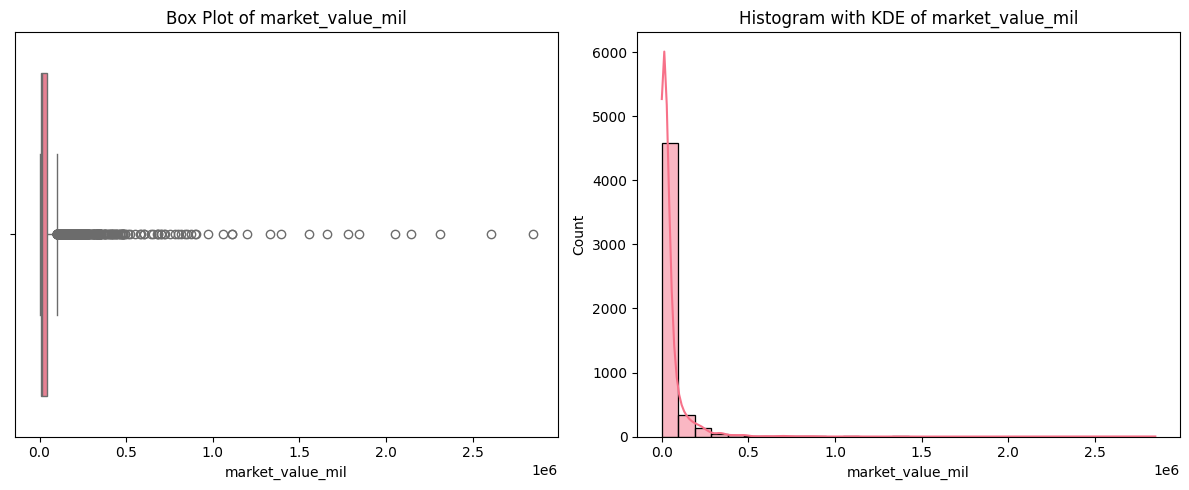


Shapiro-Wilk Test for revenue_mil:
Statistic=0.4152, p-value=0.0000
Not normal (reject H0)


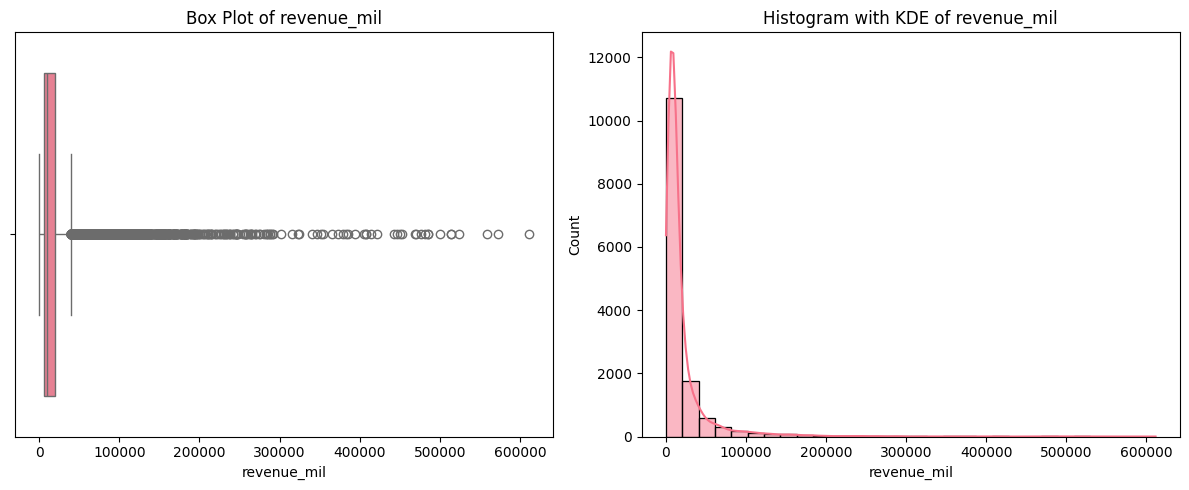


Shapiro-Wilk Test for profit_mil:
Statistic=0.4069, p-value=0.0000
Not normal (reject H0)


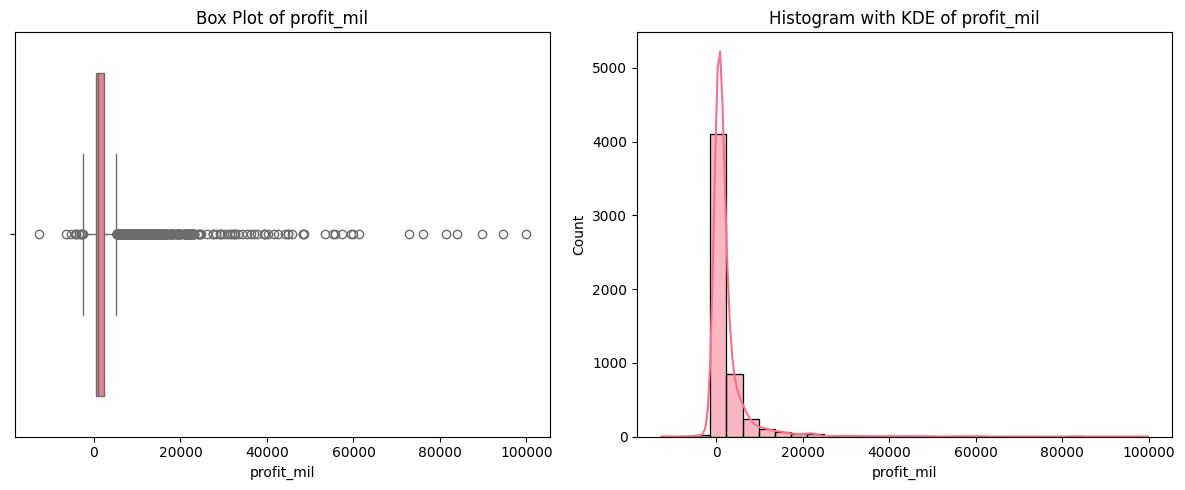


Shapiro-Wilk Test for asset_mil:
Statistic=0.2550, p-value=0.0000
Not normal (reject H0)


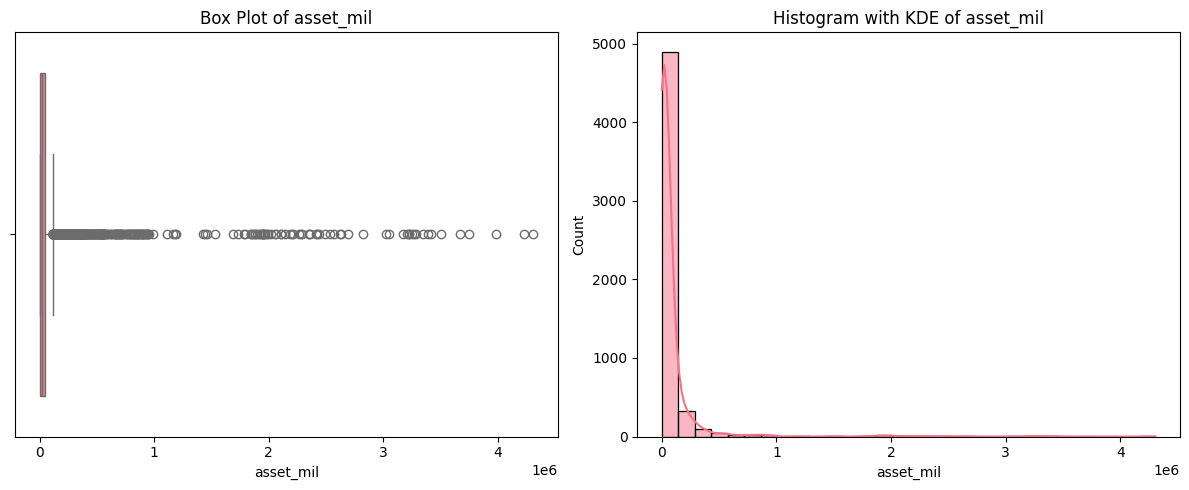

In [ ]:
# Shapiro-Wilk test for normality

financials = ['market_value_mil', 'revenue_mil', 'profit_mil', 'asset_mil']
shapiro_results = {}

for col in financials:
    col_data = df[col].dropna()  # Remove NA values
    print(f"\nShapiro-Wilk Test for {col}:")
    # Shapiro test
    sample = col_data.sample(min(len(col_data), 5000), random_state=42)
    stat, p = shapiro(sample)
    print(f"Statistic={stat:.4f}, p-value={p:.4f}")
    if p > 0.05:
        print("Likely normal distribution (fail to reject H0)")
    else:
        print("Not normal (reject H0)")
    shapiro_results[col] = (stat, p)

    # Plotting box plot and histogram side by side
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    sns.boxplot(x=col_data)
    plt.title(f'Box Plot of {col}')
    plt.xlabel(col)

    plt.subplot(1, 2, 2)
    sns.histplot(col_data, kde=True, bins=30)
    plt.title(f'Histogram with KDE of {col}')
    plt.xlabel(col)

    plt.tight_layout()
    plt.show()

The Shapiro-Wilk test was performed on major financial metrics: market value, revenue, profit, and asset in millions.

The results showed all tested financial columns significantly deviate from a normal distribution, rejecting the null hypothesis of normality (p-values effectively 0).

Distribution Characteristics: The financial data distributions display high skewness, heavy tails, and a substantial presence of extreme outliers, reflecting real-world financial variability.

Box plots and histograms (with KDE) were generated for each financial column to visually confirm skewed distributions and outliers.

## 5. Bivariate Analysis

In [ ]:
correlation_matrix = df[numeric_cols].corr()
print(correlation_matrix)

                      rank      year  market_value_mil  revenue_mil  \
rank              1.000000 -0.000308         -0.351481    -0.541992   
year             -0.000308  1.000000          0.126809     0.180185   
market_value_mil -0.351481  0.126809          1.000000     0.561714   
revenue_mil      -0.541992  0.180185          0.561714     1.000000   
profit_mil       -0.413314  0.103425          0.779609     0.607453   
asset_mil        -0.295868  0.053546          0.200766     0.317259   
employees        -0.352332  0.015329          0.321117     0.704320   

                  profit_mil  asset_mil  employees  
rank               -0.413314  -0.295868  -0.352332  
year                0.103425   0.053546   0.015329  
market_value_mil    0.779609   0.200766   0.321117  
revenue_mil         0.607453   0.317259   0.704320  
profit_mil          1.000000   0.450031   0.281136  
asset_mil           0.450031   1.000000   0.131461  
employees           0.281136   0.131461   1.000000  


In [ ]:
for i in correlation_matrix.columns:
  for j in correlation_matrix.columns:
    if abs(correlation_matrix[i][j]) > 0.7 and i != j:
      print(f"Correlation between {i} and {j}: {correlation_matrix[i][j]}")

Correlation between market_value_mil and profit_mil: 0.7796091987981185
Correlation between revenue_mil and employees: 0.7043199584941108
Correlation between profit_mil and market_value_mil: 0.7796091987981185
Correlation between employees and revenue_mil: 0.7043199584941108


## 6. Time Series Analysis

In [ ]:
# 1. Year-over-year trend analysis (aggregating average metrics by year)
yearly_trends = df.groupby('year').agg({
    'revenue_mil': 'mean',
    'profit_mil': 'mean',
    'market_value_mil': 'mean',
    'asset_mil': 'mean'
}).reset_index()

print("Yearly Average Trends:")
print(yearly_trends.tail(15))

Yearly Average Trends:
    year   revenue_mil   profit_mil  market_value_mil     asset_mil
13  2009  21403.246693          NaN               NaN           NaN
14  2010  19526.957800          NaN               NaN           NaN
15  2011  21596.311423          NaN               NaN           NaN
16  2012  23529.902806          NaN               NaN           NaN
17  2013  15758.807280  1640.658200      17618.571453   51300.68474
18  2014  24421.006000  2160.620000      34459.823404   74061.85400
19  2015  25046.394000  1889.076000      37372.774678   76292.42200
20  2016  23990.060000  2205.914000      36183.017058   77077.36800
21  2017  24111.748000  2034.591182      41322.397872   80389.34000
22  2018  25628.980000  2255.298597      45748.116525   84236.93800
23  2019  27442.626000  2542.708000      47924.569915   85912.84600
24  2020  28420.200000  2742.706000      43264.241525   92165.81800
25  2021  27526.188000  2612.138000      68813.345263  102074.52800
26  2022  32179.226000  3

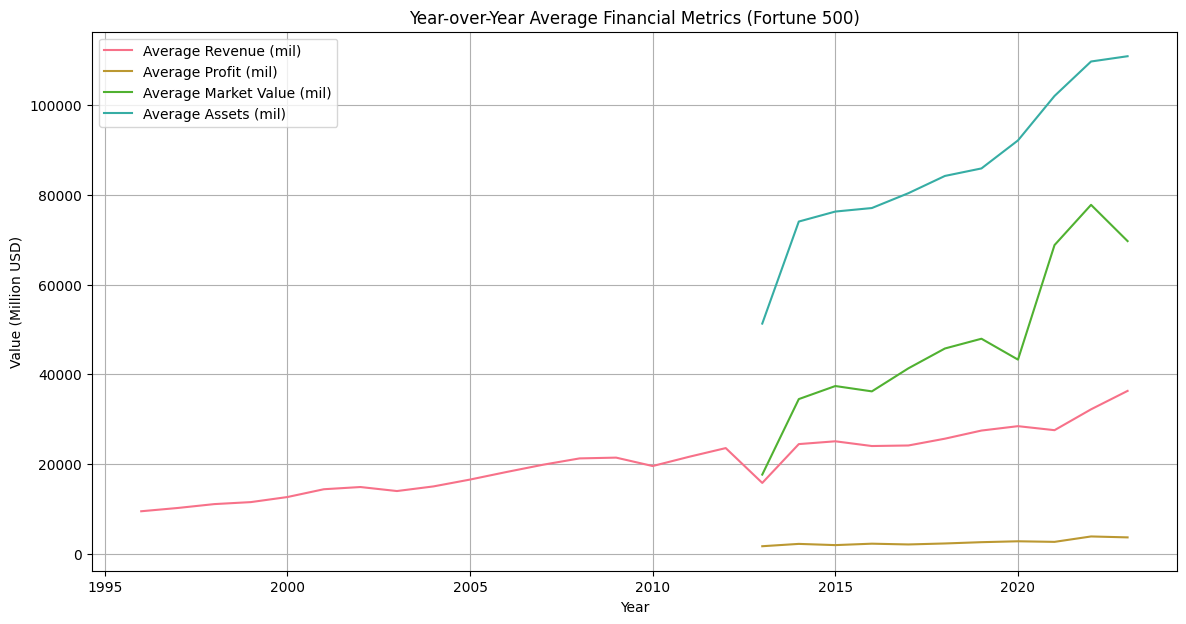

In [ ]:
plt.figure(figsize=(14, 7))

# Plotting each financial metric as a separate line
sns.lineplot(data=yearly_trends, x='year', y='revenue_mil', label='Average Revenue (mil)')
sns.lineplot(data=yearly_trends, x='year', y='profit_mil', label='Average Profit (mil)')
sns.lineplot(data=yearly_trends, x='year', y='market_value_mil', label='Average Market Value (mil)')
sns.lineplot(data=yearly_trends, x='year', y='asset_mil', label='Average Assets (mil)')

plt.title('Year-over-Year Average Financial Metrics (Fortune 500)')
plt.xlabel('Year')
plt.ylabel('Value (Million USD)')
plt.legend()
plt.grid(True)
plt.show()



1.  The average revenue shows a continuous upward trend spanning the entire period from 1996 to 2023, reflecting steady growth in earnings among the Fortune 500 companies.
2.   In contrast, the average profit, market value, and assets start their visible upward trends later, around 2013, suggesting that significant gains in these areas have accelerated primarily in the last decade.







In [ ]:
# 2. Calculate year-over-year growth rates (percentage change) for revenue
yearly_trends['revenue_growth_pct'] = yearly_trends['revenue_mil'].pct_change() * 100
yearly_trends['profit_growth_pct'] = yearly_trends['profit_mil'].pct_change() * 100

print("\nYear-over-Year Growth Rates:")
print(yearly_trends[['year', 'revenue_growth_pct', 'profit_growth_pct']])


Year-over-Year Growth Rates:
    year  revenue_growth_pct  profit_growth_pct
0   1996                 NaN                NaN
1   1997            7.731734                NaN
2   1998            8.500787                NaN
3   1999            4.045402                NaN
4   2000            9.828415                NaN
5   2001           13.819881                NaN
6   2002            3.421927                NaN
7   2003           -6.036290                NaN
8   2004            7.417483                NaN
9   2005           10.179415                NaN
10  2006           10.243398                NaN
11  2007            8.903575                NaN
12  2008            7.118811                NaN
13  2009            0.812562                NaN
14  2010           -8.766375                NaN
15  2011           10.597419                NaN
16  2012            8.953341                NaN
17  2013          -33.026467                NaN
18  2014           54.967350          31.692268
19  2015  

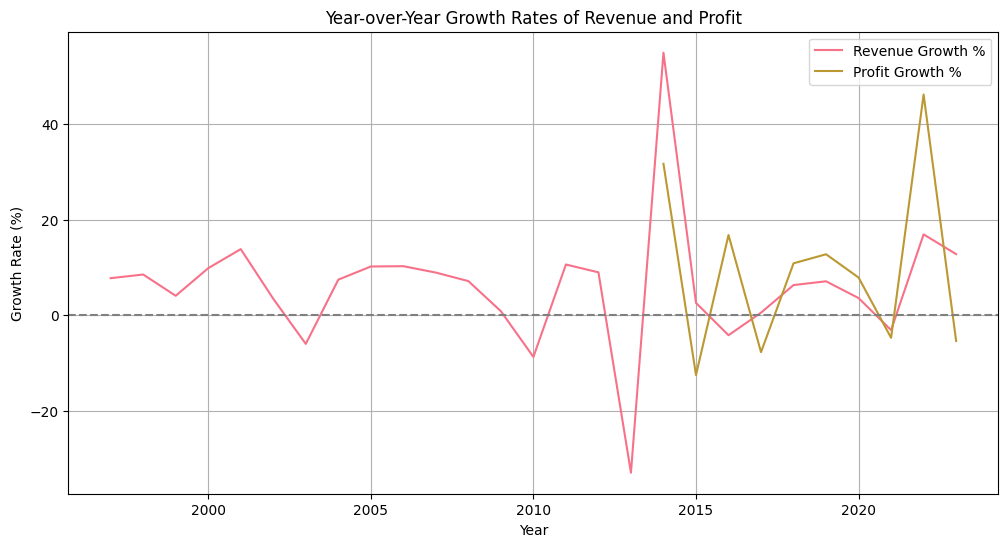

In [ ]:
plt.figure(figsize=(12, 6))

sns.lineplot(data=yearly_trends, x='year', y='revenue_growth_pct', label='Revenue Growth %')
sns.lineplot(data=yearly_trends, x='year', y='profit_growth_pct', label='Profit Growth %')

plt.title('Year-over-Year Growth Rates of Revenue and Profit')
plt.xlabel('Year')
plt.ylabel('Growth Rate (%)')
plt.axhline(0, color='grey', linestyle='--')  # Reference line at 0%
plt.legend()
plt.grid(True)
plt.show()




1. The year-over-year growth rates for revenue and profit show significant fluctuations, with sharp peaks around 2014 for revenue (above 50%) and around 2021 for profit (over 40%), indicating strong recovery or expansion in those years.
2. Notable drops below zero occurred around 2011 and 2013 for revenue and notably large profit contractions around 2014 and 2020, reflecting challenging economic periods or industry disruptions impacting Fortune 500 companies.



In [ ]:
# 3. Identify companies with consistent Fortune 500 presence
presence_counts = df.groupby('name')['year'].nunique().reset_index().rename(columns={'year':'years_present'})
consistent_companies = presence_counts[presence_counts['years_present'] >= 20]

print("\nCompanies with consistent Fortune 500 presence (>=20 years):")
print(consistent_companies.sort_values('years_present', ascending=False).head(10))


Companies with consistent Fortune 500 presence (>=20 years):
                      name  years_present
44     Abbott Laboratories             28
704   Edison International             28
1088     Johnson & Johnson             28
2029          U.S. Bancorp             28
1468         Owens Corning             26
795    Fifth Third Bancorp             24
778             Fannie Mae             24
1111               KeyCorp             24
845            Freddie Mac             22
1328        Morgan Stanley             21


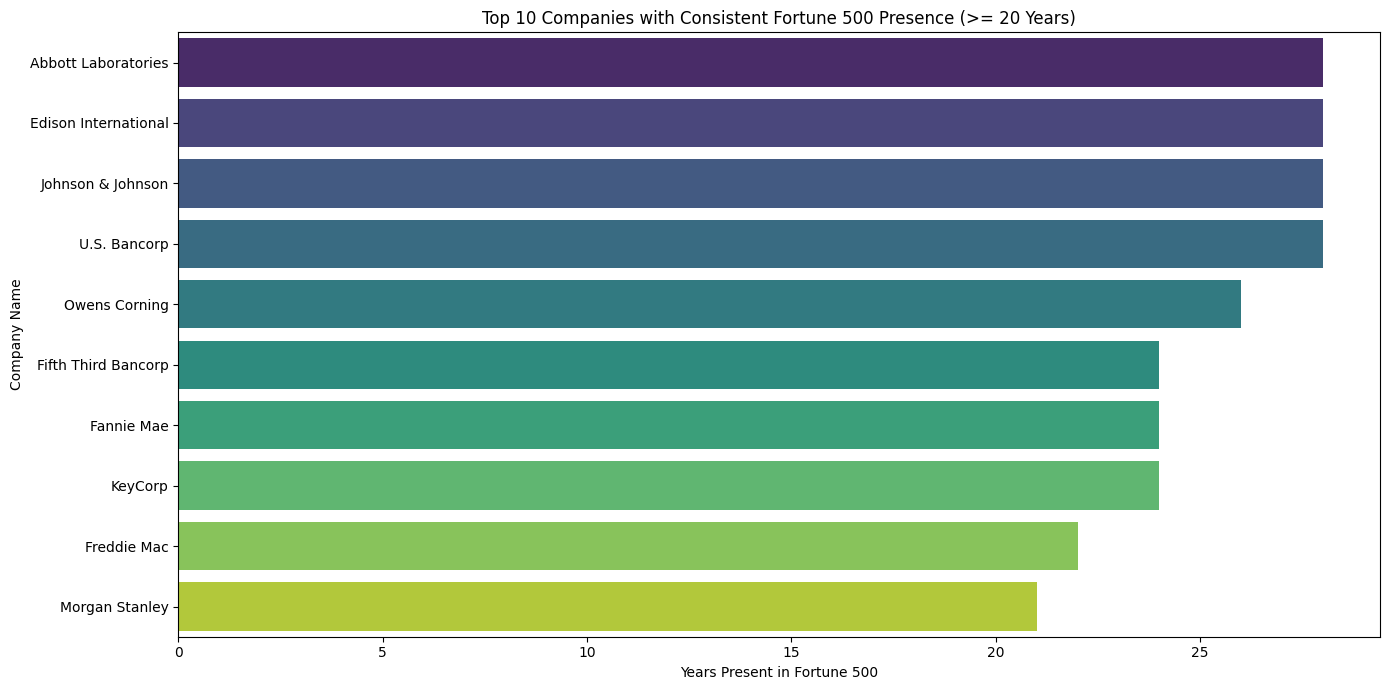

In [ ]:
# Sort top 10 consistent companies by years present descending
top_companies = consistent_companies.sort_values('years_present', ascending=False).head(10)

plt.figure(figsize=(14, 7))
sns.barplot(data=top_companies, x='years_present', y='name', palette='viridis')

plt.title('Top 10 Companies with Consistent Fortune 500 Presence (>= 20 Years)')
plt.xlabel('Years Present in Fortune 500')
plt.ylabel('Company Name')
plt.tight_layout()
plt.show()



1.   Abbott Laboratories, Edison International, and Johnson & Johnson lead the list, each appearing in the Fortune 500 for 28 consecutive years, demonstrating exceptional stability and sustained performance
2.   The chart highlights a select group of companies—including U.S. Bancorp, Fannie Mae, and Morgan Stanley—that have maintained Fortune 500 status for two decades or more, reflecting long-term resilience and business continuity
3. The top 10 companies shown have all maintained a place in the Fortune 500 for 20 years or more, demonstrating their exceptional resilience and enduring market leadership over time


In [ ]:
# 4. Document temporal patterns: summarize temporal presence and growth
print("\nTemporal Patterns Summary:")
print(f"Data covers years from {df['year'].min()} to {df['year'].max()}")
print(f"Number of unique companies over time: {df['name'].nunique()}")
print(f"Number of companies with consistent presence: {len(consistent_companies)}")


Temporal Patterns Summary:
Data covers years from 1996 to 2023
Number of unique companies over time: 2255
Number of companies with consistent presence: 15


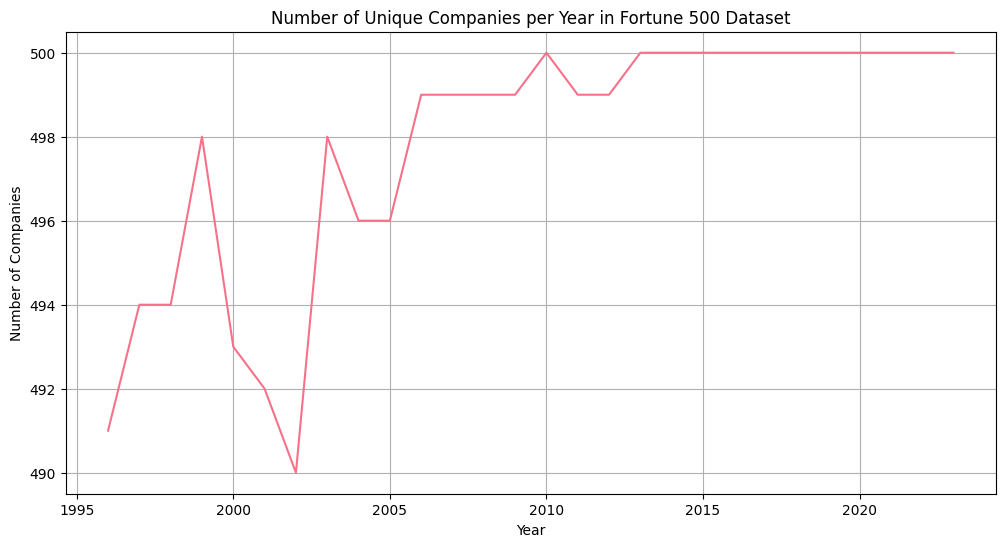

In [ ]:
companies_per_year = df.groupby('year')['name'].nunique().reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(data=companies_per_year, x='year', y='name')
plt.title('Number of Unique Companies per Year in Fortune 500 Dataset')
plt.xlabel('Year')
plt.ylabel('Number of Companies')
plt.grid(True)
plt.show()



1.  The number of unique companies appearing in the Fortune 500 dataset per year has remained remarkably consistent, stabilizing near 500 since the early 2000s, which underlines the regular updating and broad representation within the list
2.  Occasional dips in the late 1990s and early 2000s suggest periods of greater turnover or changes in data coverage, but recent years reflect a highly stable Fortune 500 cohort size.
3.  The graph shows that the count of unique companies per year in the Fortune 500 stabilizes at nearly 500 since the early 2000s, demonstrating strong consistency in the annual company cohort size
4.  Fluctuations in the 1990s indicate periods of higher turnover or coverage change, while post-2005 the list reaches full regularity, underscoring robust Fortune 500 reporting and industry representation



## 7. Key Insights Summary

6. Time Series Analysis:   
*  **Actionable Insight:** Temporal analysis reveals both broad macroeconomic cycles and micro-level volatility in financials, sector shifts, and company rank changes.
*   **Data Quality Recommendation:** Use consistent date formats and interpolate cautiously if using yearly time-points with missing entries.
*   **Next Step:** Overlay external macroeconomic events (e.g., recessions) on time series to enrich interpretation and strengthen business relevance.











## Part 2: Statistical Visualizations

### 1. Revenue Trends Over Time


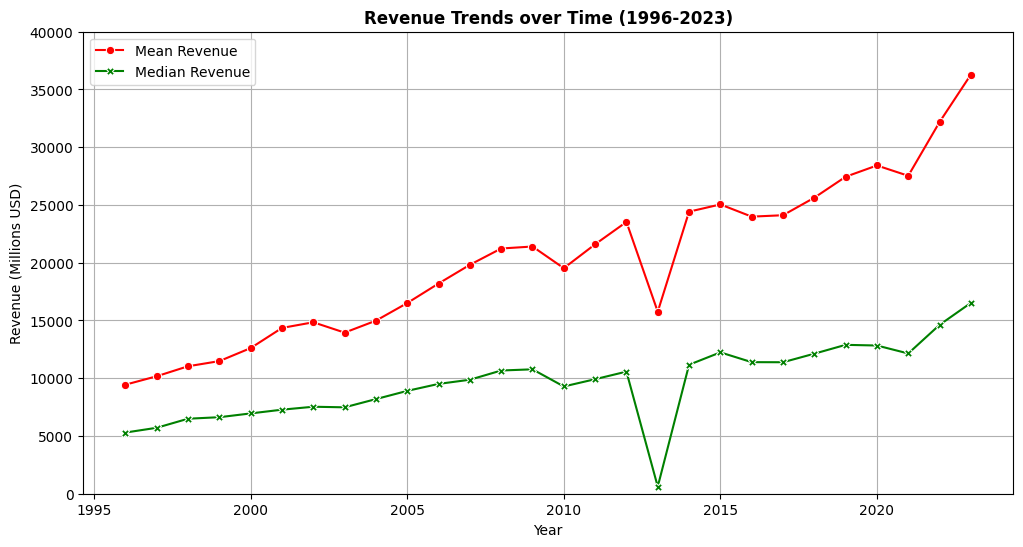

In [ ]:
plt.figure(figsize=(12, 6))
yearly_revenue = df.groupby('year')['revenue_mil'].agg({'mean','median'})

#Plotting mean and median revenue
sns.lineplot(data=yearly_revenue, x=yearly_revenue.index, y='mean', label='Mean Revenue', marker='o', color='red')
sns.lineplot(data=yearly_revenue, x=yearly_revenue.index, y='median', label='Median Revenue', marker='X', color='green')

plt.title('Revenue Trends over Time (1996-2023)', fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Revenue (Millions USD)')
plt.ylim(0, 40000)
plt.grid(True)
plt.legend()
plt.show()

### 2. Industry Distribution

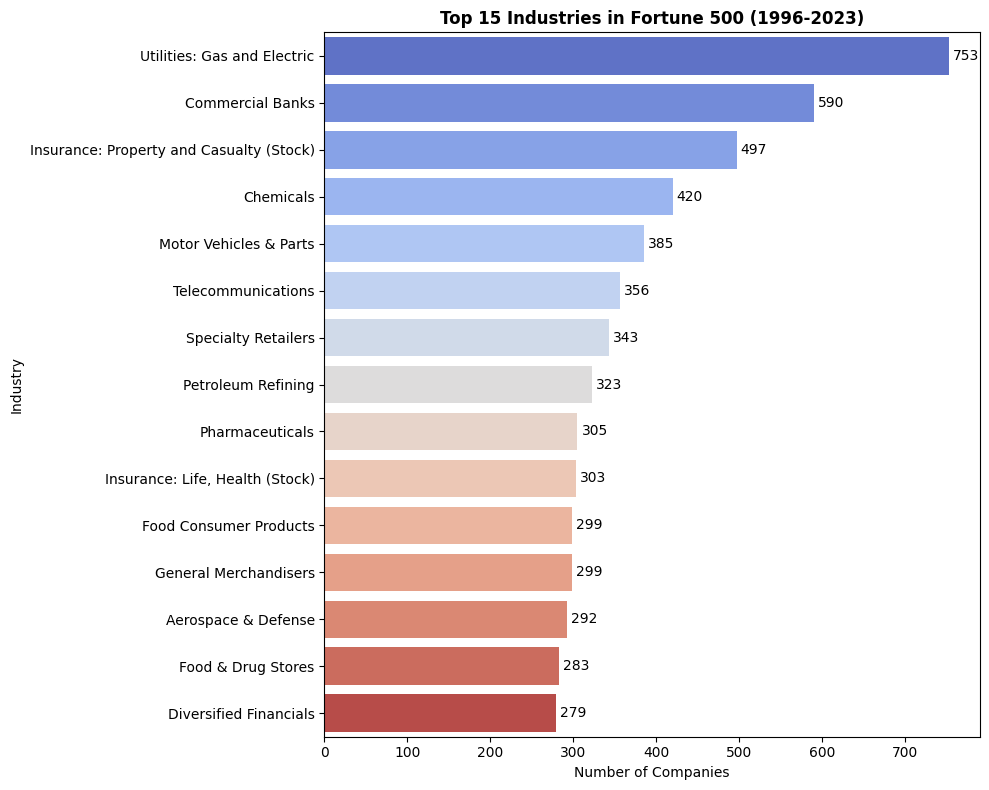

In [ ]:
top_15_industries = df['industry'].value_counts().head(15)

plt.figure(figsize=(10, 8))
ax = sns.barplot(x=top_15_industries.values, y=top_15_industries.index, palette='coolwarm')

plt.title('Top 15 Industries in Fortune 500 (1996-2023)', fontweight='bold')
plt.xlabel('Number of Companies')
plt.ylabel('Industry')

# Adding values on the bars
for p in ax.patches:
    width = p.get_width()
    plt.text(width + 5,
             p.get_y() + p.get_height() / 2,
             '{:,.0f}'.format(width),
             ha='left',
             va='center')


plt.tight_layout()
plt.show()

### 3. Geographic Distribution By State

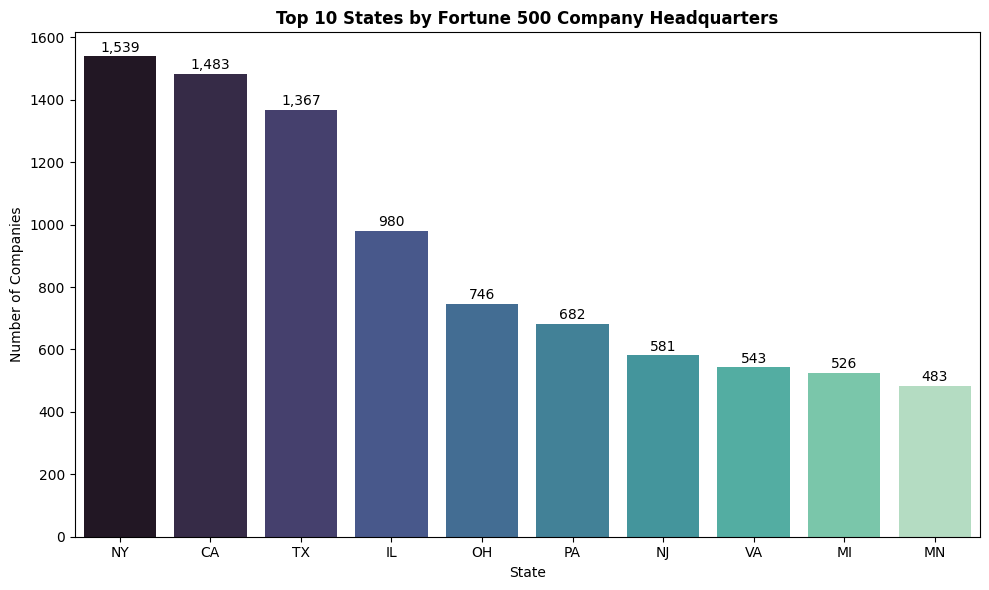

In [ ]:
# Calculating the frequency of company HQs in each state
top_10_states = df['headquarters_state'].value_counts().head(10)

plt.figure(figsize=(10, 6))
ax = sns.barplot(x=top_10_states.index, y=top_10_states.values, palette='mako')

plt.title('Top 10 States by Fortune 500 Company Headquarters', fontweight='bold')
plt.xlabel('State')
plt.ylabel('Number of Companies')

# Add values on the bars
for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x() + p.get_width() / 2.,
            height + 5,
            '{:,.0f}'.format(height),
            ha='center',
            va='bottom')


plt.tight_layout()
plt.show()

### 4. Top Companies By Recent Revenue

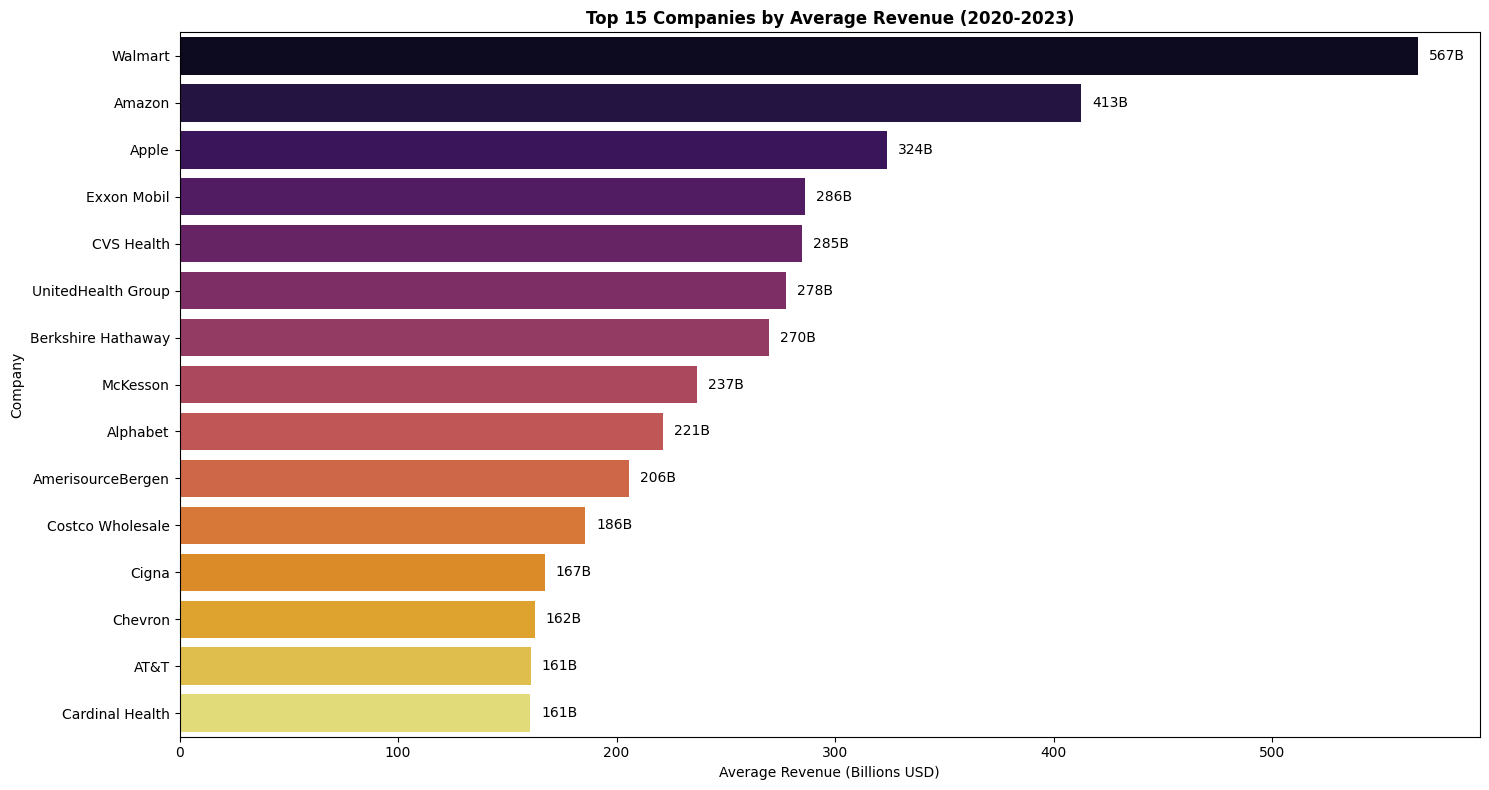

In [ ]:
# Filter data for years 2020 to 2023
df_after_2020 = df[df['year'] >= 2020]

# Calculating average revenue for each company
top_15_companies_recent_revenue =(df_after_2020.groupby('name')['revenue_mil'].mean().nlargest(15)/1000).reset_index()

# Plotting a bar chart
plt.figure(figsize=(15, 8))
ax = sns.barplot(x='revenue_mil', y='name', data=top_15_companies_recent_revenue, palette='inferno')
plt.title('Top 15 Companies by Average Revenue (2020-2023)', fontweight='bold')
plt.xlabel('Average Revenue (Billions USD)')
plt.ylabel('Company')

# Add values on the bars
for p in ax.patches:
    width = p.get_width()
    plt.text(width + 5,
             p.get_y() + p.get_height() / 2,
             '{:,.0f}B'.format(width),
             ha='left',
             va='center')

plt.tight_layout()
plt.show()

In [ ]:
top_15_companies_recent_revenue

,name,revenue_mil
0,Walmart,566.78950
1,Amazon,412.59775
2,Apple,323.70850
3,Exxon Mobil,286.44000
4,CVS Health,285.01500
5,UnitedHealth Group,277.76375
6,Berkshire Hathaway,269.57725
7,McKesson,236.89100
8,Alphabet,221.21425
9,AmerisourceBergen,205.51475


### 5. Financial Metrics Correlation Heatmap

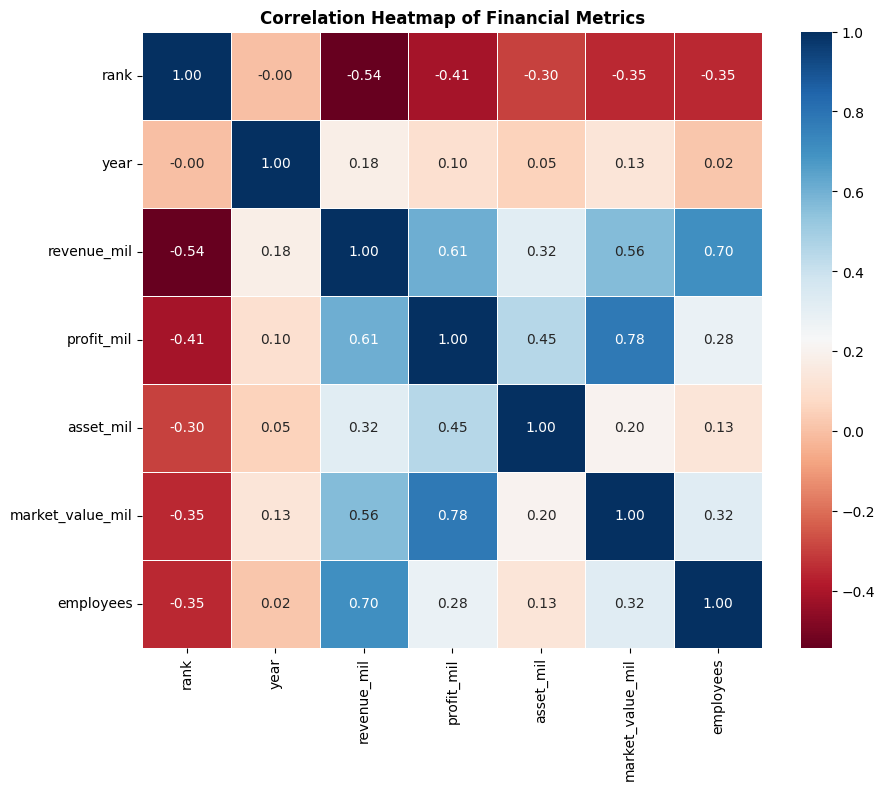

In [ ]:
financial_cols = ['rank', 'year','revenue_mil', 'profit_mil', 'asset_mil', 'market_value_mil','employees']

corr_matrix = df[financial_cols].corr()

# Creating heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='RdBu', fmt=".2f", linewidths=.5)

plt.title('Correlation Heatmap of Financial Metrics', fontweight='bold')
plt.show()

### 6. Profit Margin Distribution By Sector

Text(0.5, 0, 'Profit Margin (%)')

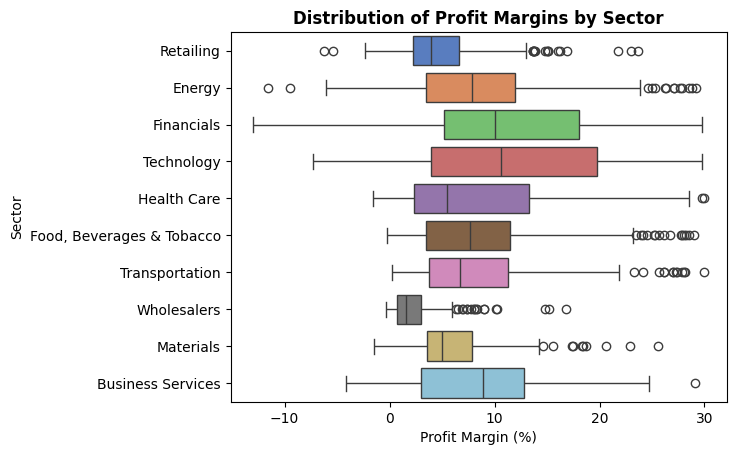

In [ ]:
# Removing rows that have missing values in profit, revenue, or sector
df_with_profit_margin = df.dropna(subset =['profit_mil','revenue_mil', 'sector'])

# Keeping only companies with positive revenue
df_with_profit_margin = df_with_profit_margin[df_with_profit_margin['revenue_mil'] > 0]

# Profit margin as a percentage
df_with_profit_margin['profit_margin'] = (df_with_profit_margin['profit_mil'] / df_with_profit_margin['revenue_mil']) * 100

# Filtering out extreme profit margin values
df_filtered = df_with_profit_margin[(df_with_profit_margin['profit_margin'] >= -20) & (df_with_profit_margin['profit_margin'] <= 30)]

# Identifying and keeping top 10 sectors
top_10 = df_filtered['sector'].value_counts().head(10).index
df_top_10 = df_filtered[df_filtered['sector'].isin(top_10)]

boxplot = sns.boxplot(data=df_top_10, x='profit_margin', y='sector', palette='muted')

plt.title('Distribution of Profit Margins by Sector', fontweight='bold')
plt.ylabel('Sector')
plt.xlabel('Profit Margin (%)')

###Advanced Visualizations:

### 1. Company Growth Trajectories


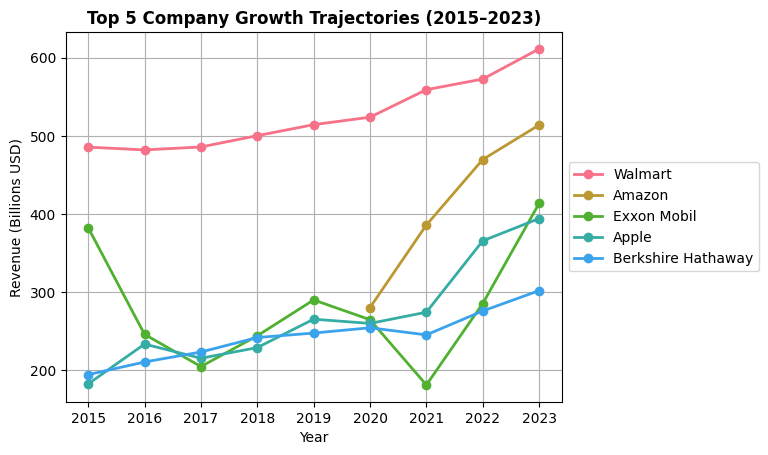

In [ ]:
# Filter years >= 2015 and get top 5 companies by mean revenue
recent_years = df[df['year'] >= 2015]
top5 = (recent_years.groupby('name')['revenue_mil'].mean().nlargest(5).index)

for company in top5:
    company_data = recent_years[recent_years['name'] == company].sort_values('year')
    plt.plot(company_data['year'], company_data['revenue_mil']/1000, marker='o', linewidth=2, label=company[:20])

# Plot each company's revenue over time
plt.title('Top 5 Company Growth Trajectories (2015–2023)', fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Revenue (Billions USD)')
plt.grid(True)
plt.legend(loc="center left", bbox_to_anchor=(1, 0.5))
plt.show()

### 2. Employee vs Revenue Relationship

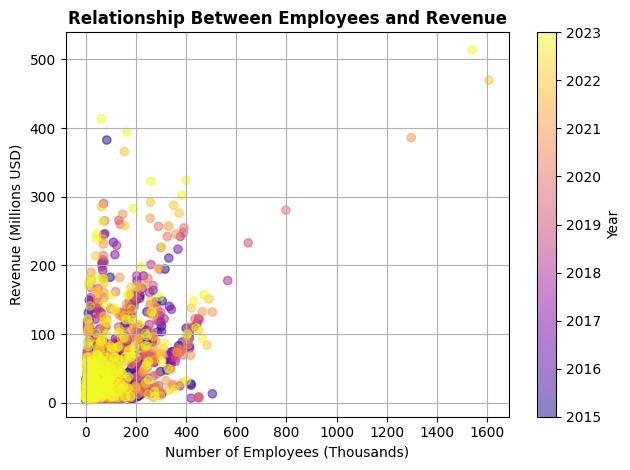

In [ ]:
rev_emp = df.dropna(subset = ['employees','revenue_mil'])

# Removing extreme values
rev_emp = rev_emp[rev_emp['employees'] < 2000000]

plt.scatter(rev_emp['employees']/1000, rev_emp['revenue_mil']/1000,alpha=0.5 ,c=rev_emp['year'], cmap = 'plasma')

plt.title('Relationship Between Employees and Revenue', fontweight='bold')
plt.xlabel('Number of Employees (Thousands)')
plt.ylabel('Revenue (Millions USD)')
plt.grid(True)
plt.tight_layout()
plt.colorbar(label='Year')
plt.show()

# Part 3: Regression Analysis

### Overall Linear Regression

LINEAR REGRESSION ANALYSIS
Intercept (β₀): 13300.64
Slope (β₁): 0.2536
R-squared: 0.4961
Correlation coefficient: 0.7043
Root Mean Squared Error (RMSE): 32759.08

STATSMODELS SUMMARY:
                            OLS Regression Results                            
Dep. Variable:            revenue_mil   R-squared:                       0.496
Model:                            OLS   Adj. R-squared:                  0.496
Method:                 Least Squares   F-statistic:                     4428.
Date:                Fri, 03 Oct 2025   Prob (F-statistic):               0.00
Time:                        19:44:08   Log-Likelihood:                -53171.
No. Observations:                4500   AIC:                         1.063e+05
Df Residuals:                    4498   BIC:                         1.064e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    s

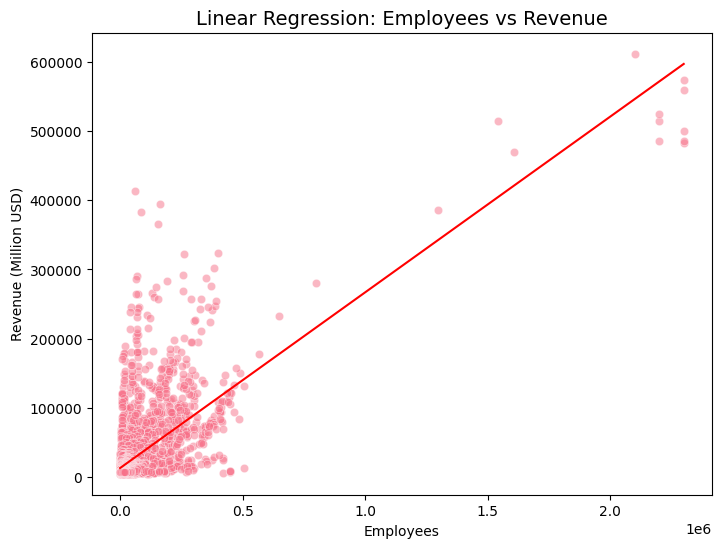

In [ ]:

# LINEAR REGRESSION: REVENUE VS EMPLOYEES (OVERALL MODEL)

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import statsmodels.api as sm

print("="*80)
print("LINEAR REGRESSION ANALYSIS")
print("="*80)

# Drop missing values for relevant variables
df_reg = df[['employees', 'revenue_mil']].dropna()

# Independent variable (X) = Employees
X = df_reg[['employees']]
# Dependent variable (y) = Revenue
y = df_reg['revenue_mil']

# ------------------------------------------------
# Fit the linear regression model
# ------------------------------------------------
linreg = LinearRegression()
linreg.fit(X, y)

# Predictions
y_pred = linreg.predict(X)

# ------------------------------------------------
# Model evaluation
# ------------------------------------------------
print("Intercept (β₀):", round(linreg.intercept_, 2))
print("Slope (β₁):", round(linreg.coef_[0], 4))
print("R-squared:", round(r2_score(y, y_pred), 4))

# Correlation coefficient
corr = np.corrcoef(X['employees'], y)[0, 1]
print("Correlation coefficient:", round(corr, 4))

# RMSE
rmse = np.sqrt(mean_squared_error(y, y_pred))
print("Root Mean Squared Error (RMSE):", round(rmse, 2))

# ------------------------------------------------
# Hypothesis Testing with Statsmodels
# ------------------------------------------------
X_sm = sm.add_constant(X)  # add intercept term
model_sm = sm.OLS(y, X_sm).fit()
print("\nSTATSMODELS SUMMARY:")
print(model_sm.summary())

# ------------------------------------------------
# Visualization of regression line
# ------------------------------------------------
plt.figure(figsize=(8,6))
sns.scatterplot(x=X['employees'], y=y, alpha=0.5)
sns.lineplot(x=X['employees'], y=y_pred, color='red')
plt.title("Linear Regression: Employees vs Revenue", fontsize=14)
plt.xlabel("Employees")
plt.ylabel("Revenue (Million USD)")
plt.show()


## Insights from Overall Linear Regression : Employees vs Revenue

* **Strong positive relationship**: Correlation = **0.70**; larger firms tend to earn more.
* **Explained variance**: R² = **0.50** → about half of revenue differences come from workforce size.
* **Impact**: Each extra employee adds ≈ **$253K** in revenue on average.
* **Limitations**: RMSE is high, meaning revenue also depends heavily on **industry and efficiency**, not just headcount.
* **Takeaway**: Bigger workforces boost revenue, but productivity and industry context matter just as much.


### Year-by-Year Analysis

   Year    n     slope     intercept        r2
0  2015  500  0.227216  12870.650112  0.449806
1  2016  500  0.217524  11865.251783  0.498723
2  2017  500  0.223729  11504.576708  0.519036
3  2018  500  0.232357  12524.006875  0.507984
4  2019  500  0.250921  13047.388678  0.495770
5  2020  500  0.258656  13318.813783  0.499131
6  2021  500  0.263227  12188.227691  0.568768
7  2022  500  0.272858  15976.769642  0.519861
8  2023  500  0.309581  17461.367887  0.477281


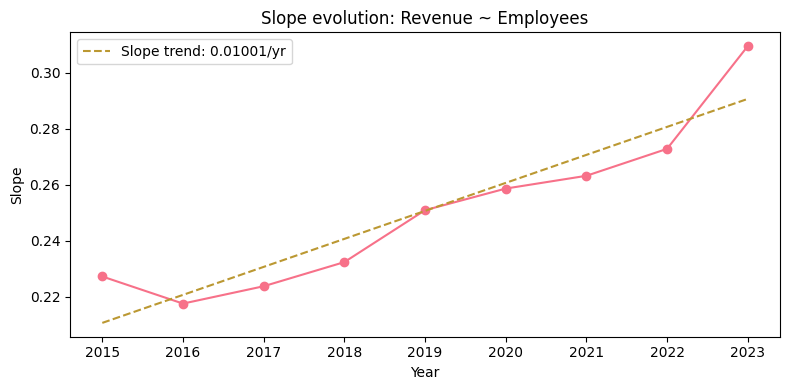

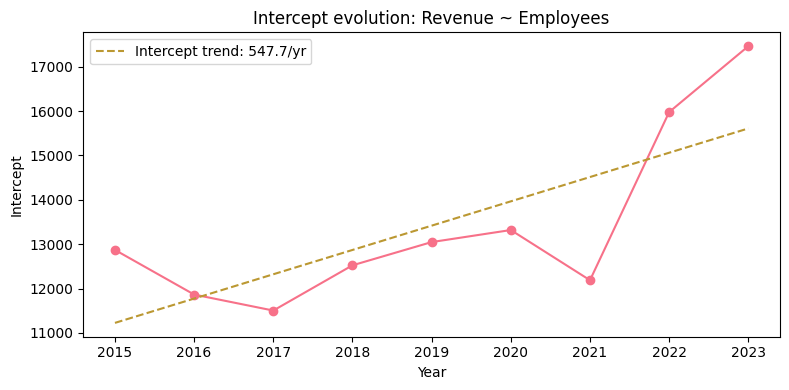

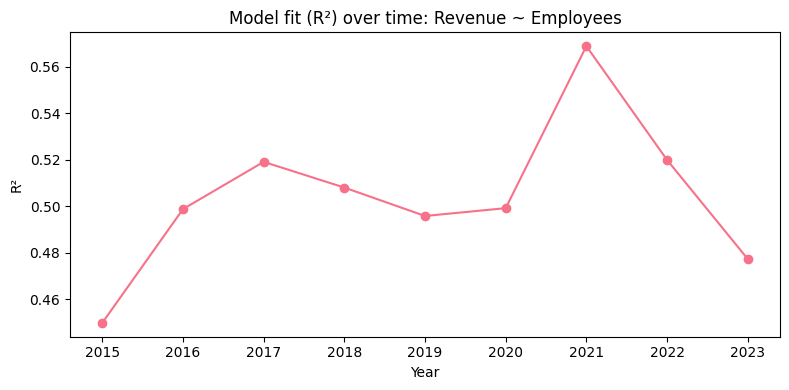

In [ ]:
df["employees_clean"] = pd.to_numeric(df["employees"], errors="coerce")
df["revenue_clean"]   = pd.to_numeric(df["revenue_mil"], errors="coerce")

# Fit separate models for each year (minimum 10 observations)
df = df[df["year"] >= 2015].dropna(subset=["employees_clean", "revenue_clean"])

MIN_OBS_PER_YEAR = 10

def fit_year_by_year(data, min_obs=10):
    rows = []
    for yr, g in data.groupby("year"):
        if len(g) < min_obs:
            continue
        x = g["employees_clean"].to_numpy(dtype=float)
        y = g["revenue_clean"].to_numpy(dtype=float)

        # Simple linear regression via polyfit: y = slope*x + intercept
        slope, intercept = np.polyfit(x, y, 1)

        y_hat = slope * x + intercept
        ss_res = np.sum((y - y_hat) ** 2)
        ss_tot = np.sum((y - y.mean()) ** 2)
        r2 = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan

        rows.append({"Year": int(yr), "n": len(g),
                     "slope": slope, "intercept": intercept, "r2": r2})
    return pd.DataFrame(rows).sort_values("Year").reset_index(drop=True)

params = fit_year_by_year(df, MIN_OBS_PER_YEAR)


print(params)

# Track parameter evolution over time
def add_trend(ax, x_years, yvals, label_prefix):
    if len(x_years) >= 2 and np.isfinite(yvals).all():
        m, b = np.polyfit(x_years, yvals, 1)
        ax.plot(x_years, m * x_years + b, "--", label=f"{label_prefix} trend: {m:.4g}/yr")
        ax.legend()

# Identify trends in slope and intercept changes
if not params.empty:
    years = params["Year"].to_numpy()
    # 1) Slope
    fig1 = plt.figure(figsize=(8,4))
    ax1 = plt.gca()
    ax1.plot(years, params["slope"].to_numpy(), marker="o")
    add_trend(ax1, years, params["slope"].to_numpy(), "Slope")
    ax1.set_title("Slope evolution: Revenue ~ Employees")
    ax1.set_xlabel("Year")
    ax1.set_ylabel("Slope")
    plt.tight_layout()
    plt.show()

    # 2) Intercept
    fig2 = plt.figure(figsize=(8,4))
    ax2 = plt.gca()
    ax2.plot(years, params["intercept"].to_numpy(), marker="o")
    add_trend(ax2, years, params["intercept"].to_numpy(), "Intercept")
    ax2.set_title("Intercept evolution: Revenue ~ Employees")
    ax2.set_xlabel("Year")
    ax2.set_ylabel("Intercept")
    plt.tight_layout()
    plt.show()

    # 3) R^2
    fig3 = plt.figure(figsize=(8,4))
    ax3 = plt.gca()
    ax3.plot(years, params["r2"].to_numpy(), marker="o")
    ax3.set_title("Model fit (R²) over time: Revenue ~ Employees")
    ax3.set_xlabel("Year")
    ax3.set_ylabel("R²")
    plt.tight_layout()
    plt.show()

else:
    print(f"No years have at least {MIN_OBS_PER_YEAR} observations after filtering.")




1.  **Slope Evolution: Revenue - Employees:**


*   The slope values have generally increased over time, indicating a growing association between company size (employees) and revenue in recent years.
*   The yellow dashed trend line shows a positive yearly trend, quantified as approximately 0.0101 increase in slope per year, meaning the incremental effect per employee has been rising annually.




2.   **Intercept Evolution: Revenue - Employees:**


*   The intercept fluctuates across years but displays an upward trend, as indicated by the yellow dashed trend line (about +547.7 units per year).
*   he rising intercept suggests that baseline revenue (after adjusting for employees) has increased over time for companies.




3.   **Model Fit (R²) Over Time:**


*   There are clear variations in R² year by year, but the overall fit remains fairly substantial, suggesting employee count is a relevant predictor for company revenue across all observed years.
*   Tracking R² helps identify which years had stronger or weaker predictive relationships—useful for further analysis and business recommendations.



# Parameter Evolution



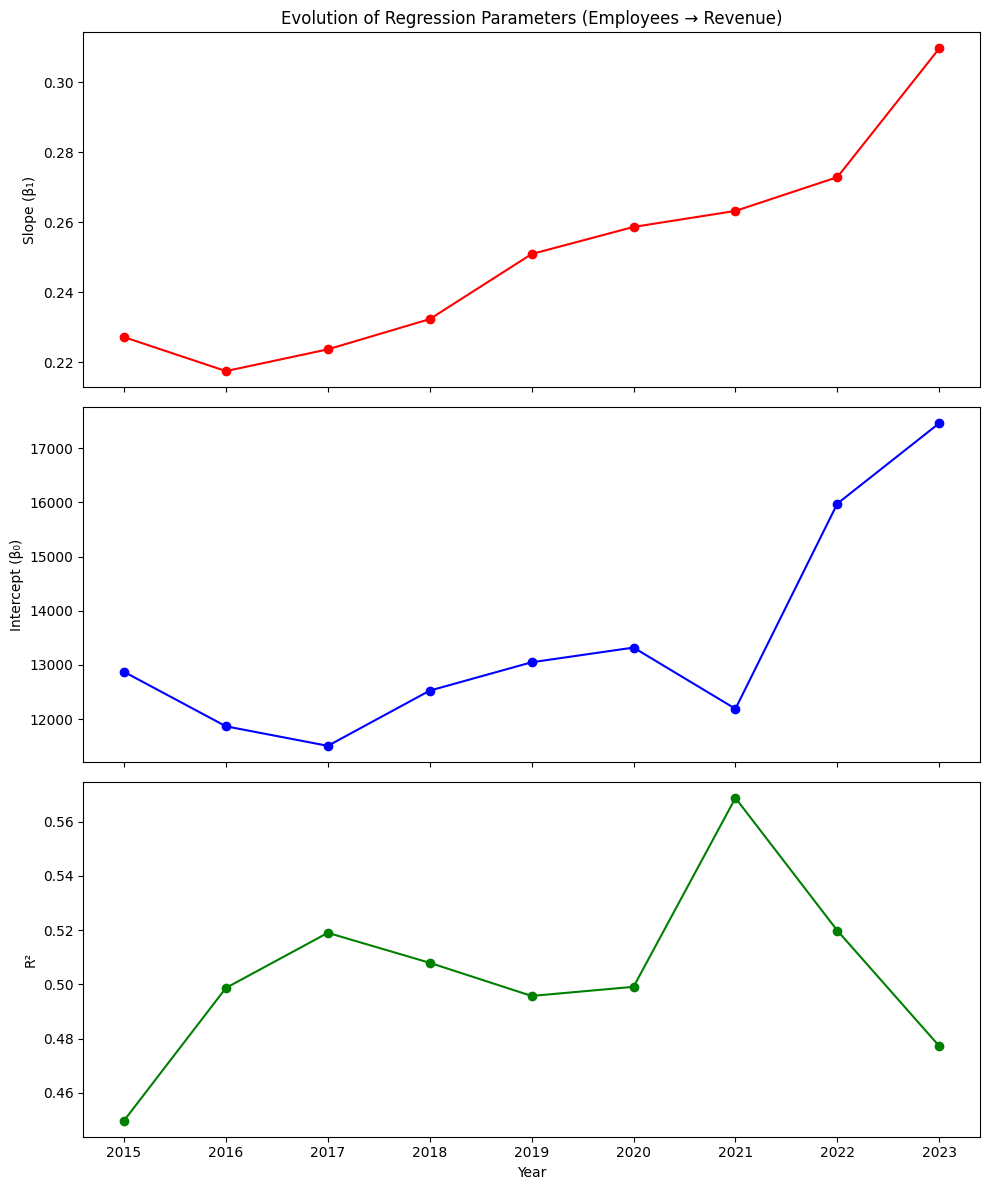

Parameter Evolution Results:
   year     intercept     slope        r2
0  2015  12870.650112  0.227216  0.449806
1  2016  11865.251783  0.217524  0.498723
2  2017  11504.576708  0.223729  0.519036
3  2018  12524.006875  0.232357  0.507984
4  2019  13047.388678  0.250921  0.495770


In [ ]:
# Ensure year is integer
df['year'] = df['year'].astype(int)

# Store results
results = []

for yr, data in df.groupby('year'):
    X = data[['employees']].dropna()
    y = data['revenue_mil'].loc[X.index]

    if len(X) > 10:  # only run regression if enough data points
        X_const = sm.add_constant(X)
        model = sm.OLS(y, X_const).fit()

        results.append({
            'year': yr,
            'intercept': model.params['const'],
            'slope': model.params['employees'],
            'r2': model.rsquared
        })

# Convert to DataFrame
evolution_df = pd.DataFrame(results)

# Plot slopes, intercepts, and R² evolution
fig, axes = plt.subplots(3, 1, figsize=(10, 12), sharex=True)

axes[0].plot(evolution_df['year'], evolution_df['slope'], marker='o', color='red')
axes[0].set_ylabel("Slope (β₁)")
axes[0].set_title("Evolution of Regression Parameters (Employees → Revenue)")

axes[1].plot(evolution_df['year'], evolution_df['intercept'], marker='o', color='blue')
axes[1].set_ylabel("Intercept (β₀)")

axes[2].plot(evolution_df['year'], evolution_df['r2'], marker='o', color='green')
axes[2].set_ylabel("R²")
axes[2].set_xlabel("Year")

plt.tight_layout()
plt.show()

print("Parameter Evolution Results:")
print(evolution_df.head())


From 2015 to 2019, the slope rose from 0.227 to 0.251, showing that revenue per employee increased over time. The intercept stayed fairly stable around 12–13K, while R² peaked in 2017 at 0.52 before slightly declining, suggesting that although productivity per employee improved, company revenue has become less dependent on workforce size alone.